In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
import os

print("✅ All libraries imported!")
print("TensorFlow:", tf.__version__)

✅ All libraries imported!
TensorFlow: 2.21.0


In [2]:
# Paths
DATASET_PATH = r"C:\Users\Prishu Baranwal\dataset\food-101\food-101\images"
MODEL_SAVE_PATH = r"C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier.h5"

# Model config
IMG_SIZE = 224        # MobileNetV2 expects 224x224
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 101     # 101 food categories

print(f"✅ Config set!")
print(f"📁 Dataset: {DATASET_PATH}")
print(f"💾 Model will be saved to: {MODEL_SAVE_PATH}")

✅ Config set!
📁 Dataset: C:\Users\Prishu Baranwal\dataset\food-101\food-101\images
💾 Model will be saved to: C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier.h5


In [3]:
# Image augmentation for training (prevents overfitting)
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values to 0-1
    rotation_range=20,        # Randomly rotate images
    width_shift_range=0.2,    # Randomly shift horizontally
    height_shift_range=0.2,   # Randomly shift vertically
    shear_range=0.2,          # Shear transformation
    zoom_range=0.2,           # Random zoom
    horizontal_flip=True,     # Flip images horizontally
    validation_split=0.2      # 80% train, 20% validation
)

# Training data
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Validation data
val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print(f"\n✅ Data prepared!")
print(f"🍽️  Training samples   : {train_generator.samples}")
print(f"🍽️  Validation samples : {val_generator.samples}")
print(f"📦 Total classes      : {train_generator.num_classes}")

Found 80800 images belonging to 101 classes.
Found 20200 images belonging to 101 classes.

✅ Data prepared!
🍽️  Training samples   : 80800
🍽️  Validation samples : 20200
📦 Total classes      : 101


In [4]:
# Load MobileNetV2 pre-trained on ImageNet (without top layer)
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,        # Remove original classifier
    weights='imagenet'        # Use pre-trained weights
)

# Freeze base model layers (we don't retrain these)
base_model.trainable = False

# Add our custom classification layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)      # Reduce feature maps to 1D
x = Dense(512, activation='relu')(x) # Fully connected layer
x = Dropout(0.3)(x)                  # Prevent overfitting
x = Dense(256, activation='relu')(x) # Another FC layer
output = Dense(NUM_CLASSES, activation='softmax')(x)  # Final output

# Build final model
model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model built successfully!")
print(f"Total layers     : {len(model.layers)}")
print(f"Trainable layers : {len([l for l in model.layers if l.trainable])}")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ Model built successfully!
Total layers     : 159
Trainable layers : 5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,071,141 (11.72 MB)

 Trainable params: 813,157 (3.10 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
import os
os.makedirs(r"C:\Users\Prishu Baranwal\calorie-tracker\models", exist_ok=True)

callbacks = [
    # Save best model automatically
    ModelCheckpoint(
        MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # Stop training if no improvement
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate if stuck
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        verbose=1
    )
]

print("✅ Callbacks ready!")

✅ Callbacks ready!


In [6]:
print("🚀 Starting training...")
print("⏳ This will take 30-60 mins depending on your system, be patient!\n")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete!")

🚀 Starting training...
⏳ This will take 30-60 mins depending on your system, be patient!

Epoch 1/10
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.3290 - loss: 2.7608
Epoch 1: val_accuracy improved from None to 0.42698, saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier.h5



Epoch 1: finished saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier.h5
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 1920s 759ms/step - accuracy: 0.3290 - loss: 2.7608 - val_accuracy: 0.4270 - val_loss: 2.2909 - learning_rate: 0.0010
Epoch 2/10
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.4109 - loss: 2.3584
Epoch 2: val_accuracy improved from 0.42698 to 0.45342, saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier.h5



Epoch 2: finished saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier.h5
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 1311s 519ms/step - accuracy: 0.4109 - loss: 2.3584 - val_accuracy: 0.4534 - val_loss: 2.1881 - learning_rate: 0.0010
Epoch 3/10
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.4328 - loss: 2.2654
Epoch 3: val_accuracy improved from 0.45342 to 0.46589, saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier.h5



Epoch 3: finished saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier.h5
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 1305s 517ms/step - accuracy: 0.4328 - loss: 2.2654 - val_accuracy: 0.4659 - val_loss: 2.1423 - learning_rate: 0.0010
Epoch 4/10
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.4455 - loss: 2.2075
Epoch 4: val_accuracy improved from 0.46589 to 0.47431, saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier.h5



Epoch 4: finished saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier.h5
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 1331s 527ms/step - accuracy: 0.4455 - loss: 2.2075 - val_accuracy: 0.4743 - val_loss: 2.1128 - learning_rate: 0.0010
Epoch 5/10
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.4561 - loss: 2.1653
Epoch 5: val_accuracy improved from 0.47431 to 0.48248, saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier.h5



Epoch 5: finished saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier.h5
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 1344s 532ms/step - accuracy: 0.4561 - loss: 2.1653 - val_accuracy: 0.4825 - val_loss: 2.0775 - learning_rate: 0.0010
Epoch 6/10
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.4633 - loss: 2.1403
Epoch 6: val_accuracy did not improve from 0.48248
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 1260s 499ms/step - accuracy: 0.4633 - loss: 2.1403 - val_accuracy: 0.4789 - val_loss: 2.0808 - learning_rate: 0.0010
Epoch 7/10
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.4670 - loss: 2.1164
Epoch 7: val_accuracy did not improve from 0.48248

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 1214s 481ms/step - accuracy: 0.4670 - loss: 2.1164 - val_accuracy: 0.4809 - val_loss: 2.0929 - learning_rate: 0.0010
Epoch 8/10
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.5082 - loss: 1.9168
Epoc


Epoch 8: finished saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier.h5
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 1080s 428ms/step - accuracy: 0.5082 - loss: 1.9168 - val_accuracy: 0.5173 - val_loss: 1.9388 - learning_rate: 2.0000e-04
Epoch 9/10
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.5192 - loss: 1.8668
Epoch 9: val_accuracy improved from 0.51733 to 0.51797, saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier.h5



Epoch 9: finished saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier.h5
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 1242s 492ms/step - accuracy: 0.5192 - loss: 1.8668 - val_accuracy: 0.5180 - val_loss: 1.9254 - learning_rate: 2.0000e-04
Epoch 10/10
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.5230 - loss: 1.8514
Epoch 10: val_accuracy improved from 0.51797 to 0.51985, saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier.h5



Epoch 10: finished saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier.h5
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 1189s 471ms/step - accuracy: 0.5230 - loss: 1.8514 - val_accuracy: 0.5199 - val_loss: 1.9205 - learning_rate: 2.0000e-04
Restoring model weights from the end of the best epoch: 10.

✅ Training complete!


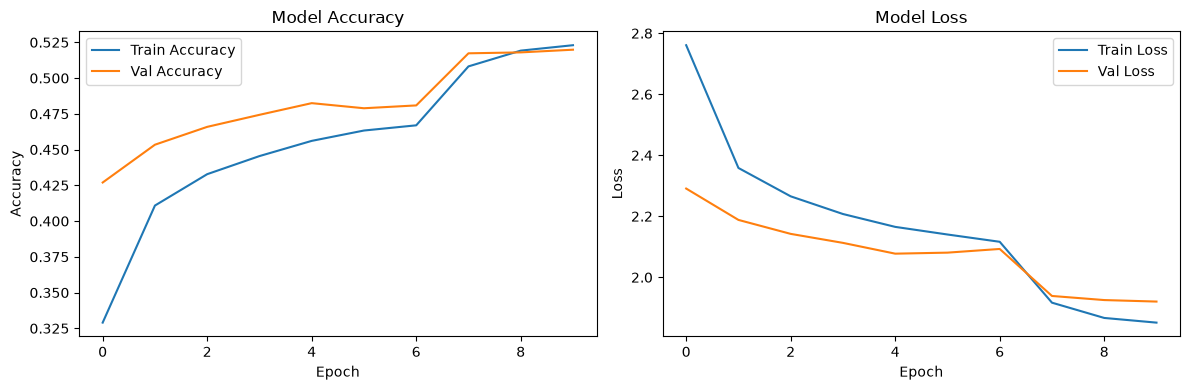


🎯 Final Validation Accuracy: 51.99%


In [7]:
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Print final accuracy
final_acc = history.history['val_accuracy'][-1]
print(f"\n🎯 Final Validation Accuracy: {final_acc*100:.2f}%")